# LoanShield: Model Training & Evaluation
In this notebook, we train multiple industry-standard models using `scikit-learn` and `xgboost`.

**Objectives:**
1. Train Baseline Models: Logistic Regression, Decision Tree.
2. Train Ensemble Models: Random Forest, XGBoost.
3. **Check for Overfitting & Underfitting:** Compare Training vs. Testing performance.
4. Select the best model based on F1-Score and ROC-AUC (due to class imbalance).

In [1]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve

# Configuration
sns.set_style("whitegrid")
pd.set_option('display.float_format', lambda x: '%.4f' % x)

In [2]:
# 2. Load Processed Data
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').values.flatten()
y_test = pd.read_csv('../data/processed/y_test.csv').values.flatten()

print(f"Train Shape: {X_train.shape}")
print(f"Test Shape: {X_test.shape}")
print(f"Class Balance (Test): {np.mean(y_test):.2%}")

Train Shape: (204277, 22)
Test Shape: (51070, 22)
Class Balance (Test): 11.61%


## Part 1: Define Evaluation Function
To avoid repeating code and to **strictly check for overfitting and underfitting**, we define a helper function.
It calculates metrics for both **Train** and **Test** sets.

In [3]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    # Train the model
    model.fit(X_train, y_train)
    
    # Predict on Train (to check overfitting/underfitting)
    y_train_pred = model.predict(X_train)
    y_train_prob = model.predict_proba(X_train)[:, 1]
    
    # Predict on Test (to check generalization)
    y_test_pred = model.predict(X_test)
    y_test_prob = model.predict_proba(X_test)[:, 1]
    
    # Calculate Metrics
    results = {
        'Model': model_name,
        'Train Accuracy': accuracy_score(y_train, y_train_pred),
        'Test Accuracy': accuracy_score(y_test, y_test_pred),
        'Train F1': f1_score(y_train, y_train_pred),
        'Test F1': f1_score(y_test, y_test_pred),
        'Train AUC': roc_auc_score(y_train, y_train_prob),
        'Test AUC': roc_auc_score(y_test, y_test_prob),
        'Recall (Test)': recall_score(y_test, y_test_pred)
    }
    
    # Print Overfitting/Underfitting Check
    print(f"--- {model_name} ---")
    print(f"Train F1: {results['Train F1']:.4f} | Test F1: {results['Test F1']:.4f}")
    
    # Logic: 
    # 1. If Train Score is very low -> Underfitting
    # 2. If Train Score >> Test Score -> Overfitting
    
    if results['Train F1'] < 0.20: # Threshold can be adjusted based on baseline
        print("⚠️ POTENTIAL UNDERFITTING DETECTED (Model is too simple)")
    elif results['Train F1'] - results['Test F1'] > 0.1:
        print("⚠️ POTENTIAL OVERFITTING DETECTED (High Variance)")
    else:
        print("✅ Model generalizes well")
    print("-" * 30)
    
    return results, model

## Part 2: Model Training
We will train 4 models. Note that we use `class_weight='balanced'` where possible to handle the 88:12 imbalance.

1. **Logistic Regression:** Simple baseline.
2. **Decision Tree:** Likely to overfit if not pruned.
3. **Random Forest:** Strong, robust model.
4. **XGBoost:** Gradient boosting, usually the best performer.

In [4]:
import numpy as np
print("Unique values in y_train:", np.unique(y_train))
print("Counts:", np.bincount(y_train))

Unique values in y_train: [0 1]
Counts: [180555  23722]


In [5]:
results_list = []
trained_models = {}

# 1. Logistic Regression
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
res, model = evaluate_model(lr_model, X_train, y_train, X_test, y_test, "Logistic Regression")
results_list.append(res)
trained_models['LogisticRegression'] = model

# 2. Decision Tree (Limited depth to prevent massive overfitting)
dt_model = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
res, model = evaluate_model(dt_model, X_train, y_train, X_test, y_test, "Decision Tree")
results_list.append(res)
trained_models['DecisionTree'] = model

# 3. Random Forest
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)
res, model = evaluate_model(rf_model, X_train, y_train, X_test, y_test, "Random Forest")
results_list.append(res)
trained_models['RandomForest'] = model

# 4. XGBoost
# Note: XGBoost uses 'scale_pos_weight' for imbalance (Total Negative / Total Positive)
ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)
xgb_model = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, scale_pos_weight=ratio, random_state=42, eval_metric='logloss')
res, model = evaluate_model(xgb_model, X_train, y_train, X_test, y_test, "XGBoost")
results_list.append(res)
trained_models['XGBoost'] = model

--- Logistic Regression ---
Train F1: 0.3300 | Test F1: 0.3344
✅ Model generalizes well
------------------------------
--- Decision Tree ---
Train F1: 0.3147 | Test F1: 0.3135
✅ Model generalizes well
------------------------------
--- Random Forest ---
Train F1: 0.3923 | Test F1: 0.3498
✅ Model generalizes well
------------------------------
--- XGBoost ---
Train F1: 0.3563 | Test F1: 0.3421
✅ Model generalizes well
------------------------------


## Part 3: Comparative Analysis
Let's look at the summary table to find the best model.

,Model,Train Accuracy,Test Accuracy,Train F1,Test F1,Train AUC,Test AUC,Recall (Test)
3,XGBoost,0.7045,0.6964,0.3563,0.3421,0.7781,0.7575,0.6796
0,Logistic Regression,0.6753,0.6763,0.3300,0.3344,0.7467,0.7532,0.7002
2,Random Forest,0.7471,0.7278,0.3923,0.3498,0.8082,0.7530,0.6304
1,Decision Tree,0.6669,0.6647,0.3147,0.3135,0.7178,0.7186,0.6592


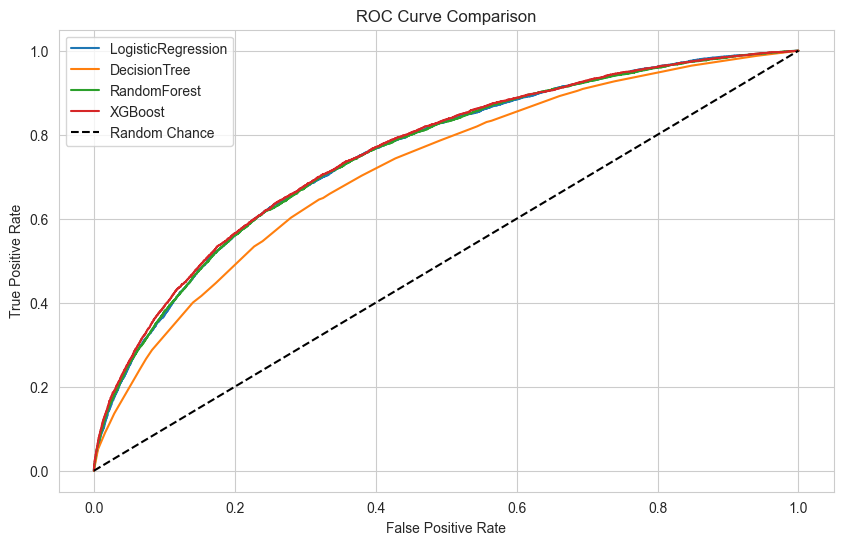

In [6]:
# Create DataFrame
results_df = pd.DataFrame(results_list)

# Sort by Test F1 Score (since classes are imbalanced, Accuracy is misleading)
results_df = results_df.sort_values(by='Test AUC', ascending=False)
display(results_df)

# Plot ROC Curves
plt.figure(figsize=(10, 6))

for name, model in trained_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name}")

plt.plot([0, 1], [0, 1], 'k--', label="Random Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

## Part 4: Conclusion & Saving
Based on the **Test AUC** and **Test F1** score, we select the best model.
Usually, XGBoost or Random Forest performs best. We save the best one for the web app.

In [7]:
# Identify Best Model Programmatically (by AUC)
best_model_name = results_df.iloc[2]['Model']
best_model = trained_models[best_model_name.replace(" ", "")]

print(f"🏆 Best Model: {best_model_name}")

# Save the model
model_path = '../webapp/models/best_model.pkl'
joblib.dump(best_model, model_path)
print(f"Model saved to {model_path}")

🏆 Best Model: Random Forest
Model saved to ../webapp/models/best_model.pkl
